In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
ident = pd.read_csv("sample_identity.tsv", sep="\t")
clones = ident[(ident["experiment"] == "pOXA48") & (ident["sample_type"] == "clone")].copy()
clones["variant"] = clones["condition"].str.extract(r"(PVI|PVB)")
clones = clones.dropna(subset=["variant"])

groups = ["PVI", "PVB"]

/tmp/ipykernel_1265650/951152203.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  cp = sns.catplot(


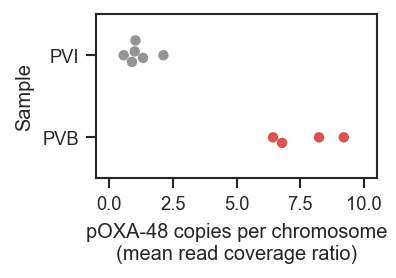

In [4]:
cp = sns.catplot(
    data=clones,
    y="variant",
    x="pOXA48_copy_number",
    kind="swarm",
    order=groups,
    palette=["xkcd:grey",
             "xkcd:pale red"],
    height=1.8,
    aspect=1.5
)

cp.set(ylabel="Sample", xlabel="pOXA-48 copies per chromosome\n(mean read coverage ratio)",
       xlim=(-.5, 10.5))

sns.despine(top=False, right=False)

plt.savefig('PVB_PVI.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('PVB_PVI.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);